# Project 2: Exploratory Data Analysis (EDA)
## E-Commerce Orders Dataset | DecodeLabs Industrial Training Kit – Batch 2026

**Objective**  
Analyze the e-commerce orders dataset to uncover patterns, trends, distributions, and outliers.  
Translate raw data into clear business insights.

**Dataset**: 1,200 orders (2023 – mid-2025)  
**Tools**: Python (pandas, numpy, matplotlib, seaborn, scipy)


## 1. Setup & Libraries

In [4]:
Project 2: Exploratory Data Analysis (EDA)
E-Commerce Orders Dataset | DecodeLabs Industrial Training Kit – Batch 2026
Objective
Analyze the e-commerce orders dataset to uncover patterns, trends, distributions, and outliers.
Translate raw data into clear business insights.

Dataset: 1,200 orders (2023 – mid-2025)
Tools: Python (pandas, numpy, matplotlib, seaborn, scipy)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load the Dataset

In [14]:
df = pd.read_excel('Dataset for Data Analytics (1) (1).xlsx')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (1200, 14)

Columns: ['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## 3. Data Overview & Quality Check

### 3.1 Basic Info

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

### 3.2 Missing Values

In [16]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Percentage (%)
CouponCode,309,25.75


### 3.3 Duplicate Check

In [17]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate OrderIDs:", df['OrderID'].duplicated().sum())

Duplicate rows: 0
Duplicate OrderIDs: 0


### 3.4 Data Consistency Check (TotalPrice vs Quantity × UnitPrice)

In [18]:
df['CalculatedTotal'] = df['Quantity'] * df['UnitPrice']
diff = (df['TotalPrice'] - df['CalculatedTotal']).abs()
print("Maximum absolute difference:", diff.max())
print("All rows match within floating-point tolerance:", diff.max() < 1e-6)

# Clean up helper column
df.drop(columns='CalculatedTotal', inplace=True)

Maximum absolute difference: 4.547473508864641e-13
All rows match within floating-point tolerance: True


## 4. Data Cleaning

- Fill missing `CouponCode` with **"No Coupon"**
- Create helper columns for easier analysis (Year, Month, YearMonth)


In [19]:
# Fill missing coupons
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')

# Date helpers
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['YearMonth'] = df['Date'].dt.to_period('M').astype(str)

print("Cleaning complete.")
print("\nCouponCode value counts after cleaning:")
print(df['CouponCode'].value_counts())

Cleaning complete.

CouponCode value counts after cleaning:
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: CouponCode, dtype: int64


## 5. Descriptive Statistics (Mandatory Requirement)

### 5.1 Numerical Summary

In [20]:
num_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,1200.00,2.95,1.41,1.00,2.00,3.00,4.00,5.00
UnitPrice,1200.00,356.41,197.18,11.39,186.06,364.21,521.57,699.93
ItemsInCart,1200.00,5.49,2.28,1.00,4.00,5.00,7.00,10.00
TotalPrice,1200.00,1053.97,819.86,11.39,410.52,823.62,1578.47,3456.40


### 5.2 Key Metrics at a Glance

In [21]:
print("=" * 50)
print("KEY BUSINESS METRICS")
print("=" * 50)
print(f"Total Orders          : {len(df):,}")
print(f"Total Revenue         : ${df['TotalPrice'].sum():,.2f}")
print(f"Average Order Value   : ${df['TotalPrice'].mean():,.2f}")
print(f"Median Order Value    : ${df['TotalPrice'].median():,.2f}")
print(f"Std Dev of Order Value: ${df['TotalPrice'].std():,.2f}")
print(f"Min Order Value       : ${df['TotalPrice'].min():,.2f}")
print(f"Max Order Value       : ${df['TotalPrice'].max():,.2f}")
print(f"Average Quantity      : {df['Quantity'].mean():.2f}")
print(f"Average Items in Cart : {df['ItemsInCart'].mean():.2f}")

KEY BUSINESS METRICS
Total Orders          : 1,200
Total Revenue         : $1,264,761.96
Average Order Value   : $1,053.97
Median Order Value    : $823.62
Std Dev of Order Value: $819.86
Min Order Value       : $11.39
Max Order Value       : $3,456.40
Average Quantity      : 2.95
Average Items in Cart : 5.49


## 6. Categorical Distributions

### 6.1 Product Distribution

Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: Product, dtype: int64


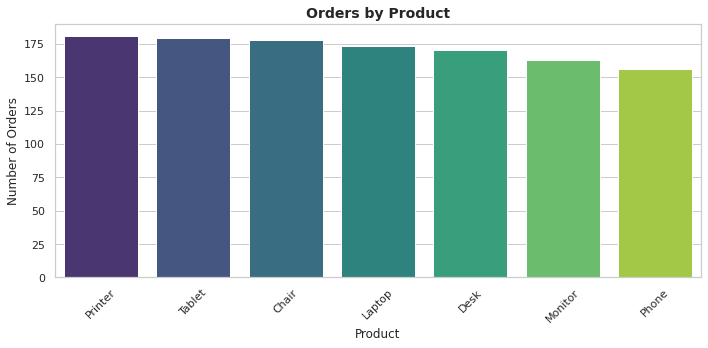

In [23]:
product_counts = df['Product'].value_counts()
print(product_counts)

plt.figure(figsize=(10, 5))
sns.barplot(x=product_counts.index,
            y=product_counts.values,
            palette='viridis')
plt.title('Orders by Product', fontsize=14, fontweight='bold')
plt.xlabel('Product')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6.2 Order Status Distribution (Critical Insight)

Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: OrderStatus, dtype: int64

--- Percentage ---
Cancelled   20.80
Returned    20.60
Pending     19.80
Shipped     19.60
Delivered   19.20
Name: OrderStatus, dtype: float64


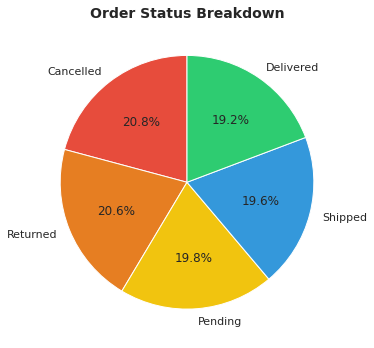

In [24]:
status_counts = df['OrderStatus'].value_counts()
print(status_counts)
print("\n--- Percentage ---")
print((status_counts / len(df) * 100).round(1))

plt.figure(figsize=(8, 5))
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#3498db', '#2ecc71']
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Order Status Breakdown', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.3 Payment Method

Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: PaymentMethod, dtype: int64


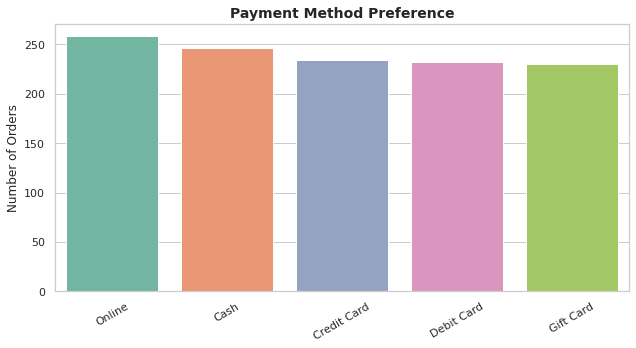

In [27]:
payment_counts = df['PaymentMethod'].value_counts()
print(payment_counts)

plt.figure(figsize=(9, 5))
sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='Set2')
plt.title('Payment Method Preference', fontsize=14, fontweight='bold')
plt.ylabel('Number of Orders')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 6.4 Referral Source

Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: ReferralSource, dtype: int64


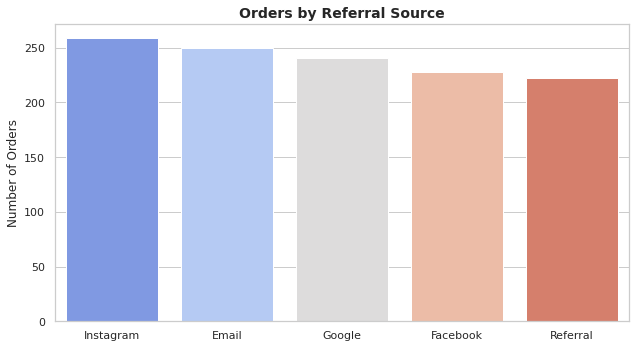

In [28]:
ref_counts = df['ReferralSource'].value_counts()
print(ref_counts)

plt.figure(figsize=(9, 5))
sns.barplot(x=ref_counts.index, y=ref_counts.values, palette='coolwarm')
plt.title('Orders by Referral Source', fontsize=14, fontweight='bold')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

### 6.5 Coupon Usage

FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: CouponCode, dtype: int64


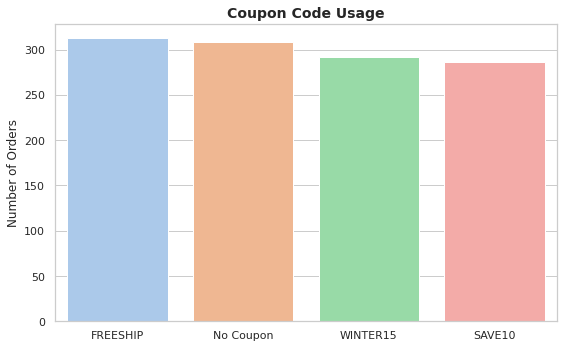

In [41]:
coupon_counts = df['CouponCode'].value_counts()
print(coupon_counts)

plt.figure(figsize=(8, 5))
sns.barplot(x=coupon_counts.index, y=coupon_counts.values, palette='pastel')
plt.title('Coupon Code Usage', fontsize=14, fontweight='bold')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

## 7. Univariate Analysis – Distributions

### 7.1 TotalPrice Distribution (Right-Skewed)

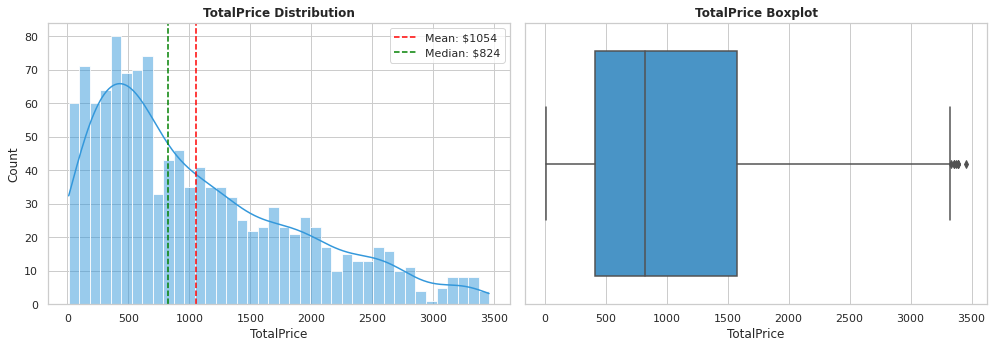

Skewness of TotalPrice: 0.89  (positive = right-skewed)


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['TotalPrice'], bins=40, kde=True, ax=axes[0], color='#3498db')
axes[0].axvline(df['TotalPrice'].mean(), color='red', linestyle='--', label=f'Mean: ${df["TotalPrice"].mean():.0f}')
axes[0].axvline(df['TotalPrice'].median(), color='green', linestyle='--', label=f'Median: ${df["TotalPrice"].median():.0f}')
axes[0].set_title('TotalPrice Distribution', fontweight='bold')
axes[0].legend()

sns.boxplot(x=df['TotalPrice'], ax=axes[1], color='#3498db')
axes[1].set_title('TotalPrice Boxplot', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Skewness of TotalPrice: {df['TotalPrice'].skew():.2f}  (positive = right-skewed)")

### 7.2 Quantity & UnitPrice Distributions

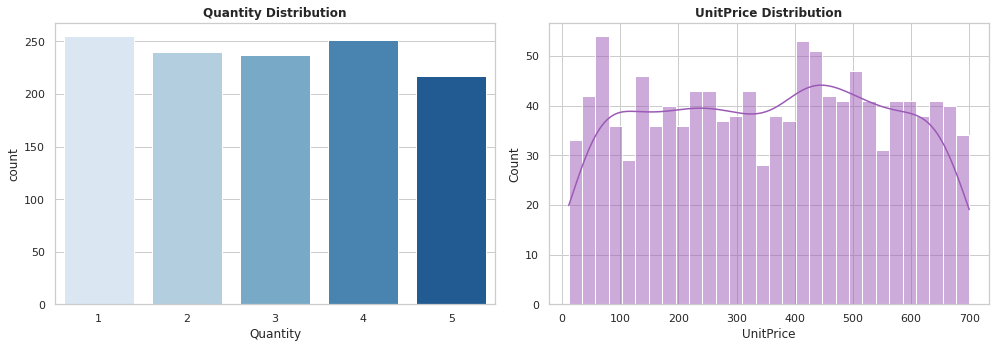

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='Quantity', data=df, ax=axes[0], palette='Blues')
axes[0].set_title('Quantity Distribution', fontweight='bold')

sns.histplot(df['UnitPrice'], bins=30, kde=True, ax=axes[1], color='#9b59b6')
axes[1].set_title('UnitPrice Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Outlier Detection (Mandatory)

We use both methods taught in the kit.

### 8.1 IQR Method (Recommended for business data)

In [32]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile): ${Q1:.2f}")
print(f"Q3 (75th percentile): ${Q3:.2f}")
print(f"IQR                 : ${IQR:.2f}")
print(f"Lower Bound         : ${lower_bound:.2f}")
print(f"Upper Bound         : ${upper_bound:.2f}")

outliers_iqr = df[(df['TotalPrice'] < lower_bound) | (df['TotalPrice'] > upper_bound)]
print(f"\nNumber of outliers (IQR method): {len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.1f}%)")

print("\nTop 10 highest TotalPrice (potential outliers):")
print(outliers_iqr[['OrderID', 'Product', 'Quantity', 'UnitPrice', 'TotalPrice', 'OrderStatus']].sort_values('TotalPrice', ascending=False).head(10))

Q1 (25th percentile): $410.52
Q3 (75th percentile): $1578.47
IQR                 : $1167.95
Lower Bound         : $-1341.41
Upper Bound         : $3330.41

Number of outliers (IQR method): 8 (0.7%)

Top 10 highest TotalPrice (potential outliers):
        OrderID  Product  Quantity  UnitPrice  TotalPrice OrderStatus
789   ORD200789   Tablet         5     691.28     3456.40   Delivered
1122  ORD201122  Monitor         5     678.19     3390.95    Returned
632   ORD200632   Laptop         5     678.16     3390.80   Delivered
469   ORD200469    Chair         5     676.98     3384.90   Cancelled
328   ORD200328   Tablet         5     674.04     3370.20   Cancelled
107   ORD200107  Printer         5     670.75     3353.75     Shipped
326   ORD200326   Laptop         5     670.48     3352.40    Returned
1065  ORD201065  Printer         5     666.80     3334.00   Delivered


### 8.2 Z-Score Method

In [33]:
z_scores = np.abs(stats.zscore(df['TotalPrice']))
outliers_z = df[z_scores > 3]

print(f"Number of outliers (Z-score > 3): {len(outliers_z)}")
print("\nThese extreme values:")
print(outliers_z[['OrderID', 'Product', 'Quantity', 'UnitPrice', 'TotalPrice']].sort_values('TotalPrice', ascending=False))

Number of outliers (Z-score > 3): 0

These extreme values:
Empty DataFrame
Columns: [OrderID, Product, Quantity, UnitPrice, TotalPrice]
Index: []


### 8.3 Interpretation of Outliers

- Most high TotalPrice values come from **high Quantity × high UnitPrice** combinations (e.g., 5 × expensive Printer/Laptop).
- These are **Signal**, not Noise — they represent legitimate high-value orders / bulk purchases.
- Recommendation: Keep them, but monitor as VIP / high-value customers.


## 9. Trends Over Time

### 9.1 Yearly Overview

      Orders   Revenue  AvgOrderValue
Year                                 
2023     510 552643.24        1083.61
2024     459 480235.87        1046.27
2025     231 231882.85        1003.82


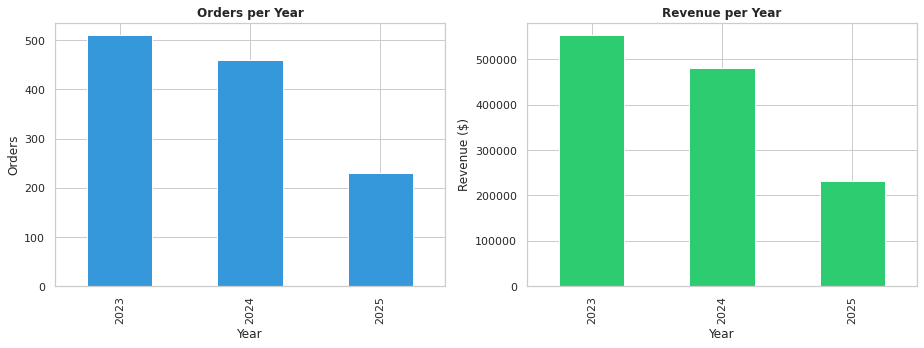

In [34]:
yearly = df.groupby('Year').agg(
    Orders=('OrderID', 'count'),
    Revenue=('TotalPrice', 'sum'),
    AvgOrderValue=('TotalPrice', 'mean')
).round(2)
print(yearly)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
yearly['Orders'].plot(kind='bar', ax=axes[0], color='#3498db')
axes[0].set_title('Orders per Year', fontweight='bold')
axes[0].set_ylabel('Orders')

yearly['Revenue'].plot(kind='bar', ax=axes[1], color='#2ecc71')
axes[1].set_title('Revenue per Year', fontweight='bold')
axes[1].set_ylabel('Revenue ($)')
plt.tight_layout()
plt.show()

### 9.2 Monthly Trend

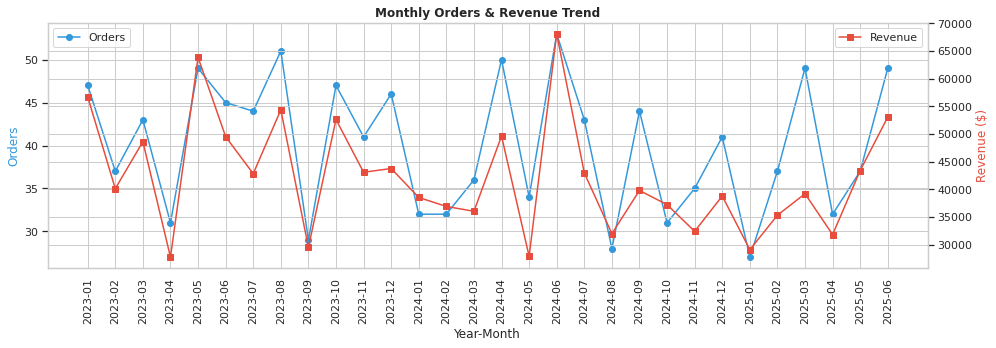

In [35]:
monthly = df.groupby('YearMonth').agg(
    Orders=('OrderID', 'count'),
    Revenue=('TotalPrice', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(monthly['YearMonth'], monthly['Orders'], color='#3498db', marker='o', label='Orders')
ax2.plot(monthly['YearMonth'], monthly['Revenue'], color='#e74c3c', marker='s', label='Revenue')

ax1.set_xlabel('Year-Month')
ax1.set_ylabel('Orders', color='#3498db')
ax2.set_ylabel('Revenue ($)', color='#e74c3c')
ax1.set_title('Monthly Orders & Revenue Trend', fontweight='bold')
ax1.tick_params(axis='x', rotation=90)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 10. Deeper Business Insights

### 10.1 Revenue by Product

         Orders  TotalRevenue  AvgOrderValue  AvgQuantity
Product                                                  
Chair       178     195620.11        1098.99         3.16
Printer     181     195612.61        1080.73         2.99
Laptop      173     192126.56        1110.56         3.09
Tablet      179     186568.95        1042.28         2.78
Monitor     163     175651.41        1077.62         2.94
Desk        170     167459.93         985.06         2.99
Phone       156     151722.39         972.58         2.63


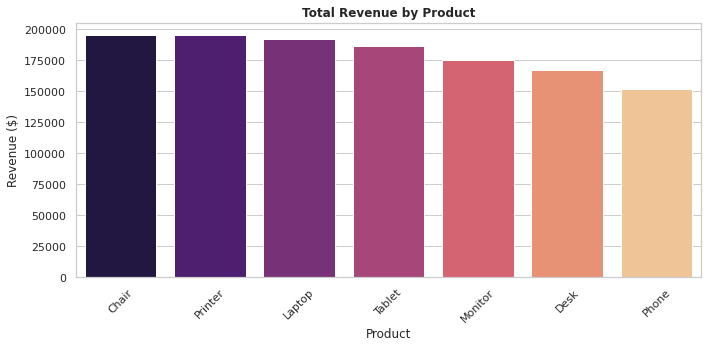

In [45]:
product_rev = df.groupby('Product').agg(
    Orders=('OrderID', 'count'),
    TotalRevenue=('TotalPrice', 'sum'),
    AvgOrderValue=('TotalPrice', 'mean'),
    AvgQuantity=('Quantity', 'mean')
).sort_values('TotalRevenue', ascending=False).round(2)
print(product_rev)

plt.figure(figsize=(10, 5))
sns.barplot(x=product_rev.index, y=product_rev['TotalRevenue'], palette='magma')
plt.title('Total Revenue by Product', fontweight='bold')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 10.2 Average Order Value by Order Status

               mean  median  count
OrderStatus                       
Cancelled   1105.58  875.48    250
Delivered   1050.22  789.57    231
Pending     1081.55  869.80    237
Returned     984.93  754.44    247
Shipped     1047.49  816.64    235


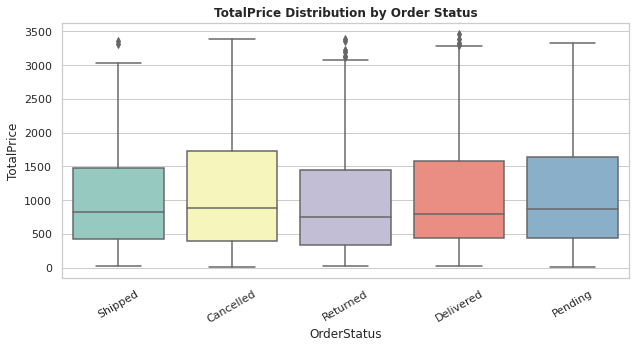

In [46]:
status_aov = df.groupby('OrderStatus')['TotalPrice'].agg(['mean', 'median', 'count']).round(2)
print(status_aov)

plt.figure(figsize=(9, 5))
sns.boxplot(x='OrderStatus', y='TotalPrice', data=df, palette='Set3')
plt.title('TotalPrice Distribution by Order Status', fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 10.3 Coupon Impact on Average Order Value

              mean  median  count
CouponCode                       
FREESHIP   1070.41  793.40    313
No Coupon  1043.37  834.12    309
SAVE10     1065.87  823.06    286
WINTER15   1035.90  838.71    292


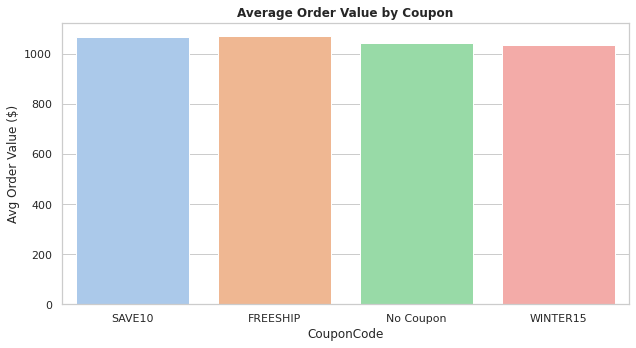

In [47]:
coupon_impact = df.groupby('CouponCode')['TotalPrice'].agg(['mean', 'median', 'count']).round(2)
print(coupon_impact)

plt.figure(figsize=(9, 5))
sns.barplot(x='CouponCode', y='TotalPrice', data=df,
            estimator=np.mean, ci=None, palette='pastel')
plt.title('Average Order Value by Coupon', fontweight='bold')
plt.ylabel('Avg Order Value ($)')
plt.tight_layout()
plt.show()

### 10.4 Referral Source Performance

In [39]:
ref_perf = df.groupby('ReferralSource').agg(
    Orders=('OrderID', 'count'),
    Revenue=('TotalPrice', 'sum'),
    AOV=('TotalPrice', 'mean')
).sort_values('Revenue', ascending=False).round(2)
print(ref_perf)

                Orders   Revenue     AOV
ReferralSource                          
Instagram          259 275285.45 1062.88
Email              250 261808.55 1047.23
Google             241 250441.48 1039.18
Facebook           228 250410.90 1098.29
Referral           222 226815.58 1021.69


## 11. Correlation Analysis

Only numerical columns are used.

             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity         1.00       0.01         0.65        0.61
UnitPrice        0.01       1.00         0.00        0.72
ItemsInCart      0.65       0.00         1.00        0.39
TotalPrice       0.61       0.72         0.39        1.00


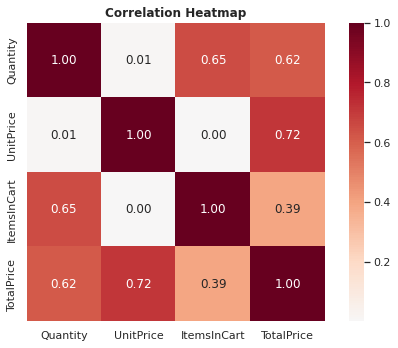

In [40]:
corr_matrix = df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].corr()
print(corr_matrix.round(3))

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', square=True)
plt.title('Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Key Findings & Business Insights

### Summary of Strongest Signals

1. **High Cancellation & Return Rate**  
   - Cancelled: ~20.8% | Returned: ~20.6%  
   - Combined ~41.4% of orders do not complete successfully.  
   - **So What?** This is a major operational and customer-experience red flag. Investigate root causes (product quality, shipping delays, expectation mismatch).

2. **Right-Skewed Order Value**  
   - Mean AOV ≈ $1,054 | Median ≈ $824  
   - Skewness is positive → a small number of high-value orders pull the average up.  
   - **So What?** Median is a better central measure. Focus on both volume (majority of customers) and VIP (high-value) segments.

3. **Product Performance is Balanced**  
   - All 7 products have similar order counts (156–181).  
   - Revenue leaders are driven more by UnitPrice × Quantity than pure volume.

4. **Coupon Usage**  
   - ~74% of orders used a coupon (FREESHIP, WINTER15, SAVE10).  
   - “No Coupon” still forms a significant segment (~26%).

5. **Outliers are Signal, not Noise**  
   - Extreme TotalPrice values are legitimate high Quantity + high UnitPrice combinations.  
   - Treat them as high-value customers rather than errors.

6. **Time Trend**  
   - 2023 had the highest order volume.  
   - 2025 data is only up to June → partial year.

7. **Referral Sources are fairly evenly distributed**  
   - Instagram leads slightly, followed by Email and Google.

### Recommendations

- **Urgent**: Deep-dive into Cancelled + Returned orders (common products, payment methods, referral sources).
- Create a VIP segment for customers with high TotalPrice / frequent high-quantity orders.
- Test whether FREESHIP drives higher conversion vs discount coupons.
- Monitor monthly trends closely as 2025 progresses.


## 13. Conclusion

This Exploratory Data Analysis has transformed the raw e-commerce orders table into clear diagnostic insights:

- We calculated all required basic statistics (mean, median, counts, etc.).
- We identified the shape of distributions (especially right-skewed TotalPrice).
- We detected outliers using both IQR and Z-score methods and classified them as **Signal**.
- We uncovered a critical business issue: high cancellation and return rates.
- We mapped trends over time and performance across products, payments, referrals, and coupons.

**Next Step**: Visualize these findings in an interactive Power BI dashboard for stakeholders.

---
*Project 2 – Exploratory Data Analysis | DecodeLabs Batch 2026*
